# Ответы на экзаменационные вопросы: файлы, форматы, сериализация

Ноутбук закрывает вопросы **11, 12, 13, 14, 15, 16, 17**, а также практические задачи из билетов
**№5 (задача 3)** и **№24/№25 (задача 3)**.

Используемые датасеты (сгенерированы синтетически в `exam/make_datasets.py`):

- `datasets/addres-book-q.xml`
- `datasets/litw-win.csv` (кодировка **windows-1251** — специально, для демонстрации вопроса 16)
- `datasets/countries-of-the-world.csv`


In [1]:
%matplotlib inline
import sys
import json
import pickle
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import make_datasets

DATA = make_datasets.DATA_DIR
make_datasets.make_all()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)



Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/msikanov/.cache/fontconfig
	/Users/msikanov/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/msikanov/.cache/fontconfig
	/Users/msikanov/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/msikanov/.cache/fontconfig
	/Users/msikanov/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/msikanov/.cache/fontconfig
	/Users/msikanov/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/msikanov/.cache/fontconfig
	/Users/msikanov/.fontconfig


Matplotlib is building the font cache; this may take a moment.


Готово. Файлы в /Users/msikanov/PycharmProjects/ege-informatics/exam/datasets:
 - addres-book-q.xml
 - anna_synthetic.txt
 - countries-of-the-world.csv
 - litw-win.csv
 - sp500hst.txt
 - sp500hst_yearly_avg.csv
 - titanic.csv
 - себестоимость_в1.xlsx
 - себестоимость_в1_recalculated.xlsx


## Вопрос 16. Текстовые и бинарные форматы файлов, кодировки, специфика русского языка, UTF-8

### Текстовый vs бинарный файл

- **Текстовый файл** — последовательность байт, которая интерпретируется как символы согласно
  заданной **кодировке** (encoding). Человек может прочитать его в обычном текстовом редакторе.
  Примеры: `.csv`, `.json`, `.xml`, `.txt`, исходный код `.py`.
- **Бинарный файл** — последовательность байт со своим, специфичным для формата, способом
  интерпретации (не текст в привычном смысле); открытие в текстовом редакторе даёт "мусор".
  Примеры: `.pickle`, `.npy`, `.hdf5`, изображения, скомпилированные `.pyc`.

### Преимущества и применение (особенно для табличных данных)

| | Текстовый (CSV/JSON) | Бинарный (Pickle/NPY/HDF5) |
|---|---|---|
| Читаемость человеком | да | нет |
| Совместимость между языками/системами | высокая | обычно только внутри экосистемы (или специфична для формата) |
| Размер файла | больше (числа как текст) | компактнее (числа как есть, часто + сжатие) |
| Скорость чтения/записи больших числовых массивов | медленнее (парсинг текста) | значительно быстрее |
| Точность чисел с плавающей точкой | может терять точность при округлении в текст | сохраняется побитово |

Для табличных данных: если важна переносимость и просматриваемость — CSV; если важна скорость и
объём (большие числовые таблицы) — бинарные форматы (NPY/HDF5/Parquet).

### Кодировки и специфика русского языка

Кодировка — правило сопоставления байтов и символов. Для русского языка исторически использовались
разные однобайтовые кодировки (**cp1251/windows-1251**, **koi8-r**, **cp866**), которые кодируют
кириллицу разными наборами байт — файл, сохранённый в одной кодировке и прочитанный в
предположении о другой, даёт "кракозябры". **UTF-8** — переменная по длине (1–4 байта на символ)
кодировка Unicode, обратно совместимая с ASCII в первом байте; кириллические буквы в ней занимают
по 2 байта. Сегодня UTF-8 — стандарт по умолчанию и для файлов, и для передачи данных в сети,
так как однозначно кодирует любой язык и не требует заранее договариваться о кодировке отдельно.

In [2]:
text = "Привет, мир!"
print("длина строки в символах:", len(text))
print("длина в байтах UTF-8:     ", len(text.encode("utf-8")))
print("длина в байтах CP1251:    ", len(text.encode("cp1251")))

# что происходит при несовпадении кодировок
raw_cp1251 = text.encode("cp1251")
try:
    print("\nнеправильное декодирование cp1251-байт как utf-8:", raw_cp1251.decode("utf-8"))
except UnicodeDecodeError as e:
    print("\nпопытка прочитать cp1251-байты как utf-8 -> ошибка:", e)

# наш датасет litw-win специально сохранён в windows-1251 (типичное "наследие" русских текстовых корпусов)
with open(DATA / "litw-win.csv", "rb") as f:
    raw = f.read(40)
print("\nсырые первые байты файла litw-win.csv:", raw)
print("если прочитать как utf-8, получим мусор:", raw.decode("utf-8", errors="replace"))
print("правильно (encoding='windows-1251'):     ", raw.decode("windows-1251"))


длина строки в символах: 12
длина в байтах UTF-8:      21
длина в байтах CP1251:     12

попытка прочитать cp1251-байты как utf-8 -> ошибка: 'utf-8' codec can't decode byte 0xcf in position 0: invalid continuation byte

сырые первые байты файла litw-win.csv: b'rank;lemma;pos;ipm\r\n1;\xf1;pr;11201.2\r\n2;\xe4\xee'
если прочитать как utf-8, получим мусор: rank;lemma;pos;ipm
1;�;pr;11201.2
2;��
правильно (encoding='windows-1251'):      rank;lemma;pos;ipm
1;с;pr;11201.2
2;до


## Вопрос 17. Сериализация и десериализация: сценарии применения, способы реализации

**Сериализация** — преобразование структуры данных, находящейся в памяти программы (объект,
список, словарь, дерево объектов), в последовательность байт/символов, которую можно сохранить в
файл или передать по сети. **Десериализация** — обратное восстановление объекта из этой
последовательности.

### Сценарии применения

- сохранение состояния программы на диск (кэш, чекпоинты, конфигурация);
- обмен данными между процессами/сервисами по сети (API-ответы, сообщения в очередях);
- передача сложных объектов между разными запусками программы или между разными языками.

### Способы реализации и их специфика

- **Текстовые универсальные форматы** (JSON, XML) — переносимы между языками, читаемы человеком,
  но описывают только "простые" структуры (числа, строки, списки, словари/объекты) — сложные
  объекты Python (с методами, циклическими ссылками) нужно вручную свести к такой структуре.
- **`pickle` (специфичный для Python)** — сериализует практически любой объект Python "как есть"
  (включая пользовательские классы), но результат не читается человеком, не переносится в другие
  языки и **не является безопасным** для десериализации данных из недоверенного источника
  (десериализация `pickle` может выполнить произвольный код).
- **Бинарные форматы для чисел** (NPY, HDF5, Parquet) — специализированная, эффективная
  сериализация именно числовых массивов/таблиц.

In [3]:
class Point:
    def __init__(self, x, y):
        self.x, self.y = x, y
    def __repr__(self):
        return f"Point({self.x}, {self.y})"

obj = {"name": "маршрут", "points": [Point(0, 0), Point(1, 2), Point(3, 5)]}

blob = pickle.dumps(obj)                 # сериализация в bytes
print("сериализованный объект (bytes, нечитаемо человеком), длина:", len(blob))

restored = pickle.loads(blob)             # десериализация
print("восстановленный объект:", restored)
print("это тот же тип пользовательского класса:", type(restored["points"][0]) is Point)


сериализованный объект (bytes, нечитаемо человеком), длина: 130
восстановленный объект: {'name': 'маршрут', 'points': [Point(0, 0), Point(1, 2), Point(3, 5)]}
это тот же тип пользовательского класса: True


## Вопрос 12. Сериализация/десериализация: формат JSON

JSON (JavaScript Object Notation) — текстовый, языконезависимый формат сериализации, основанный
на двух структурах: **объект** (`{"ключ": значение, ...}`, аналог словаря) и **массив**
(`[значение, ...]`, аналог списка), а также примитивах: строка, число, `true`/`false`, `null`.

В Python модуль `json`: `json.dumps`/`json.dump` — сериализация (объект Python → JSON-строка/файл),
`json.loads`/`json.load` — десериализация (JSON → объект Python). Соответствие типов: `dict` ↔
объект, `list`/`tuple` ↔ массив, `str` ↔ строка, `int`/`float` ↔ число, `True/False/None` ↔
`true/false/null`. **Важно**: JSON не умеет сериализовать произвольные объекты Python "из коробки"
(нужно самостоятельно свести к словарю/списку, либо передать функцию `default=`).

In [4]:
person = {
    "name": "Анна Иванова",
    "age": 29,
    "is_student": False,
    "phones": ["+7-900-000-00-00", "+7-900-111-11-11"],
    "address": {"city": "Москва", "zip": "101000"},
    "middle_name": None,
}

json_str = json.dumps(person, ensure_ascii=False, indent=2)
print(json_str)

restored = json.loads(json_str)
print("\nтипы после десериализации совпадают с исходными типами Python:")
print(type(restored["age"]), type(restored["is_student"]), type(restored["phones"]), type(restored["middle_name"]))

json_path = DATA / "person.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(person, f, ensure_ascii=False, indent=2)
print(f"\nсохранено в {json_path}, прочитано обратно:", json.load(open(json_path, encoding='utf-8')) == person)


{
  "name": "Анна Иванова",
  "age": 29,
  "is_student": false,
  "phones": [
    "+7-900-000-00-00",
    "+7-900-111-11-11"
  ],
  "address": {
    "city": "Москва",
    "zip": "101000"
  },
  "middle_name": null
}

типы после десериализации совпадают с исходными типами Python:
<class 'int'> <class 'bool'> <class 'list'> <class 'NoneType'>

сохранено в /Users/msikanov/PycharmProjects/ege-informatics/exam/datasets/person.json, прочитано обратно: True


## Вопрос 13. Формат XML и модель DOM, работа с BeautifulSoup

### XML

Текстовый формат для описания структурированных, **иерархических** данных с помощью вложенных
тегов `<tag attr="...">содержимое</tag>`. В отличие от JSON, элементы XML могут иметь и атрибуты,
и текстовое содержимое, и вложенные элементы одновременно, а также допускают повтор одноимённых
тегов на одном уровне.

### DOM (Document Object Model)

Способ представления XML/HTML-документа в памяти как **дерева объектов-узлов**: узел-документ →
узлы-элементы → их атрибуты и текстовые узлы. DOM даёт программный интерфейс для навигации по
дереву (родитель/потомки/соседи) и поиска узлов, независимо от исходного текста.

### BeautifulSoup

Библиотека для парсинга XML/HTML в DOM-подобное дерево `Tag`-объектов с удобным API поиска:
`soup.find(name, attrs)`, `soup.find_all(...)`, доступ к атрибутам как к словарю (`tag['attr']`),
к тексту — `tag.text`/`tag.get_text()`, навигация — `tag.parent`, `tag.children`.

In [5]:
with open(DATA / "addres-book-q.xml", encoding="utf-8") as f:
    soup = BeautifulSoup(f, "xml")   # парсинг в DOM-дерево

print(soup.prettify()[:600], "...\n")

first_person = soup.find("person")
print("первый узел person, атрибут gender:", first_person["gender"])
print("дочерний узел <name>:", first_person.find("name").get_text())

all_people = soup.find_all("person")
print("\nвсего узлов person в дереве:", len(all_people))
males = soup.find_all("person", attrs={"gender": "male"})
print("узлов person с gender='male':", len(males))


<?xml version="1.0" encoding="utf-8"?>
<address-book>
 <person gender="male">
  <name>
   Михаил Соколов
  </name>
  <company>
   ООО ТехноПром
  </company>
  <work-phone>
   +7-937-479-41-63
  </work-phone>
  <personal-phone>
   +7-963-308-13-92
  </personal-phone>
 </person>
 <person gender="female">
  <name>
   Анна Егорова
  </name>
  <company>
   ООО ТехноПром
  </company>
  <work-phone>
   +7-966-695-17-72
  </work-phone>
  <personal-phone>
   +7-984-801-20-17
  </personal-phone>
 </person>
 <person gender="male">
  <name>
   Михаил Соколов
  </name>
  <company>
   ООО ТехноПром
  </comp ...

первый узел person, атрибут gender: male
дочерний узел <name>: Михаил Соколов

всего узлов person в дереве: 24
узлов person с gender='male': 12


## Вопрос 11. Специфика текстовых и бинарных файлов на примере CSV и Pickle

### CSV (Comma-Separated Values)

Текстовый формат для **табличных** данных: каждая строка файла — строка таблицы, значения
разделены символом-разделителем (запятая, `;`, табуляция). Плюсы: простота, читаемость,
поддержка всеми языками и табличными редакторами (Excel и т.п.). Минусы: нет типов (всё — текст,
типы нужно восстанавливать при чтении), нет вложенности, нужно договариваться о разделителе,
кавычках, кодировке.

### Pickle

Бинарный, специфичный для Python протокол сериализации произвольных объектов (см. вопрос 17).
Плюсы: сохраняет любые объекты Python и их типы "как есть", быстрее и компактнее текстовых
форматов для сложных структур. Минусы: не читается человеком, не переносится в другие языки,
несовместим между несовместимыми версиями Python/протокола, не безопасен для чтения файлов из
недоверенного источника.

In [6]:
import csv

rows = [{"name": "Иван", "age": 30}, {"name": "Анна", "age": 25}]
csv_path = DATA / "demo_people.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["name", "age"])
    writer.writeheader()
    writer.writerows(rows)

print("CSV — текстовый файл, можно посмотреть как обычный текст:")
print(csv_path.read_text(encoding="utf-8"))

pkl_path = DATA / "demo_people.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(rows, f)

print("Pickle — бинарный файл, первые байты нечитаемы как текст:")
print(pkl_path.read_bytes()[:40])

# при чтении CSV все значения приходят строками, если явно не преобразовать типы
with open(csv_path, encoding="utf-8") as f:
    csv_back = list(csv.DictReader(f))
print("\nCSV после чтения (age — строка!):", csv_back[0], type(csv_back[0]["age"]))

with open(pkl_path, "rb") as f:
    pkl_back = pickle.load(f)
print("Pickle после чтения (age — тот же int, что и был):", pkl_back[0], type(pkl_back[0]["age"]))


CSV — текстовый файл, можно посмотреть как обычный текст:
name,age
Иван,30
Анна,25

Pickle — бинарный файл, первые байты нечитаемы как текст:
b'\x80\x05\x958\x00\x00\x00\x00\x00\x00\x00]\x94(}\x94(\x8c\x04name\x94\x8c\x08\xd0\x98\xd0\xb2\xd0\xb0\xd0\xbd\x94\x8c\x03age'

CSV после чтения (age — строка!): {'name': 'Иван', 'age': '30'} <class 'str'>
Pickle после чтения (age — тот же int, что и был): {'name': 'Иван', 'age': 30} <class 'int'>


## Вопрос 14. Форматы NPY и HDF: общая характеристика и пример работы

### NPY / NPZ

Собственный бинарный формат NumPy для сохранения **одного** массива (`.npy`) или нескольких
массивов в одном архиве (`.npz`). Файл хранит небольшой заголовок (dtype, shape, порядок памяти) и
далее — сырые байты данных. Быстрое и точное (без потери точности) сохранение/загрузка массивов
NumPy: `np.save`/`np.load`, `np.savez`.

### HDF5 (Hierarchical Data Format)

Бинарный формат для хранения **больших объёмов структурированных числовых данных** в виде
иерархии (как файловая система внутри одного файла): "группы" (аналог директорий) содержат
"датасеты" (именованные многомерные массивы) и метаданные (атрибуты). Поддерживает частичное
чтение (не обязательно грузить весь файл в память), сжатие, множество наборов данных разных форм
и типов в одном файле. В Python — через `h5py` (низкий уровень, ближе к NumPy) или `pandas.HDFStore`
(таблицы Pandas).

In [7]:
import h5py

arr = np.arange(12, dtype=np.float64).reshape(3, 4)

npy_path = DATA / "demo_array.npy"
np.save(npy_path, arr)
arr_back = np.load(npy_path)
print("NPY: массив сохранён и загружен без потерь:", np.array_equal(arr, arr_back), "dtype:", arr_back.dtype)

hdf_path = DATA / "demo_data.h5"
with h5py.File(hdf_path, "w") as hf:
    grp = hf.create_group("experiment_1")
    grp.create_dataset("temperatures", data=arr, compression="gzip")
    grp.attrs["description"] = "демонстрационные данные"

with h5py.File(hdf_path, "r") as hf:
    print("\nструктура HDF5-файла:")
    hf.visit(print)
    loaded = hf["experiment_1/temperatures"][:]
    print("\nатрибут группы:", hf["experiment_1"].attrs["description"])
    print("данные совпадают с исходными:", np.array_equal(loaded, arr))


NPY: массив сохранён и загружен без потерь: True dtype: float64

структура HDF5-файла:
experiment_1
experiment_1/temperatures

атрибут группы: демонстрационные данные
данные совпадают с исходными: True


## Вопрос 15. Сравнение форматов: pickle, JSON, XML, CSV

| Формат | Тип | Структура данных | Читаемость человеком | Переносимость между языками | Когда предпочтительнее |
|---|---|---|---|---|---|
| **CSV** | текстовый | только табличная (строки/столбцы) | высокая | высокая | простые однородные таблицы, экспорт в Excel/другие системы |
| **JSON** | текстовый | вложенные объекты/массивы, примитивные типы | высокая | высокая (де-факто стандарт для API) | обмен структурированными (в т.ч. иерархическими) данными между сервисами/языками, конфиги |
| **XML** | текстовый | вложенные элементы + атрибуты, схемы (XSD), смешанное содержимое | средняя (многословнее JSON) | высокая, но тяжеловеснее | документо-ориентированные данные, где важна схема/валидация, унаследованные корпоративные форматы |
| **Pickle** | бинарный | произвольный объект Python (включая пользовательские классы, циклы ссылок) | нет | нет (только Python) | быстрое сохранение/восстановление именно Python-объектов внутри одного проекта на Python; **никогда** — для данных из недоверенного источника |

Итог: если нужна переносимость и читаемость — JSON (данные общего вида) или CSV (табличные
данные); если нужна схема/валидация и историческая совместимость с корпоративными системами —
XML; если данные не покидают Python-процесс/проект и нужно сохранить произвольные объекты —
Pickle.

## Практика: билет №5, задача 3

> По данным из файла `addres-book-q.xml` сформировать два списка кортежей: в первом — только
> мужчины, кортеж = (имя, компания, рабочий телефон); во втором — только женщины, кортеж = (имя,
> личный телефон). Сохранить списки в два разных файла формата pickle и загрузить их оттуда.

In [8]:
with open(DATA / "addres-book-q.xml", encoding="utf-8") as f:
    soup = BeautifulSoup(f, "xml")

men = [
    (p.find("name").get_text(), p.find("company").get_text(), p.find("work-phone").get_text())
    for p in soup.find_all("person", attrs={"gender": "male"})
]
women = [
    (p.find("name").get_text(), p.find("personal-phone").get_text())
    for p in soup.find_all("person", attrs={"gender": "female"})
]

print("мужчины (имя, компания, рабочий телефон), первые 3:")
for row in men[:3]:
    print(" ", row)
print("\nженщины (имя, личный телефон), первые 3:")
for row in women[:3]:
    print(" ", row)

men_path = DATA / "address_book_men.pkl"
women_path = DATA / "address_book_women.pkl"
with open(men_path, "wb") as f:
    pickle.dump(men, f)
with open(women_path, "wb") as f:
    pickle.dump(women, f)

with open(men_path, "rb") as f:
    men_loaded = pickle.load(f)
with open(women_path, "rb") as f:
    women_loaded = pickle.load(f)

print(f"\nсохранено {len(men)} мужчин в {men_path.name} и {len(women)} женщин в {women_path.name}")
print("загруженные из pickle списки совпадают с исходными:", men_loaded == men and women_loaded == women)


мужчины (имя, компания, рабочий телефон), первые 3:
  ('Михаил Соколов', 'ООО ТехноПром', '+7-937-479-41-63')
  ('Михаил Соколов', 'ООО ТехноПром', '+7-903-916-81-57')
  ('Михаил Соколов', 'ООО Ромашка', '+7-934-250-96-32')

женщины (имя, личный телефон), первые 3:
  ('Анна Егорова', '+7-984-801-20-17')
  ('Татьяна Голубева', '+7-994-365-23-48')
  ('Светлана Виноградова', '+7-975-357-97-40')

сохранено 12 мужчин в address_book_men.pkl и 12 женщин в address_book_women.pkl
загруженные из pickle списки совпадают с исходными: True


## Практика: билет №24/№25, задача 3

> Считать файлы `addres-book-q`, `litw-win`, `countries-of-the-world`. Вывести результаты
> считывания в виде массивов NumPy и Pandas. Отобразить содержимое, построить графики и
> рассчитать средние значения по столбцам там, где это применимо.

In [9]:
# --- countries-of-the-world: числовая таблица -> и NumPy (структурированный массив), и Pandas
countries_df = pd.read_csv(DATA / "countries-of-the-world.csv")
countries_np = np.genfromtxt(DATA / "countries-of-the-world.csv", delimiter=",", names=True, dtype=None, encoding="utf-8")

print("Pandas DataFrame (countries-of-the-world), первые строки:")
print(countries_df.head())
print("\nNumPy structured array, первые записи:")
print(countries_np[:3])

numeric_cols = countries_df.select_dtypes(include=[np.number]).columns
print("\nсредние значения по числовым столбцам (Pandas):\n", countries_df[numeric_cols].mean().round(2))
print("\nто же самое через NumPy structured array:")
for col in ["Population", "Area_sq_mi", "GDP__per_capita", "Literacy_", "Birthrate", "Deathrate"]:
    print(f"  {col}: {np.mean(countries_np[col]):.2f}")


Pandas DataFrame (countries-of-the-world), первые строки:
   Country                Region  Population  Area (sq. mi.)  GDP ($ per capita)  Literacy (%)  Birthrate  Deathrate
0   Russia   C.W. OF IND. STATES    86183894         8908306               59739          93.3      15.21       7.51
1  Germany        WESTERN EUROPE   727742730         3294532               64466          56.9      11.91       7.02
2   France        WESTERN EUROPE  1156843074         6832365               53659          62.9      43.35       9.62
3   Brazil   LATIN AMER. & CARIB   990055604         7903740               42625          90.6      37.91       4.11
4    China  ASIA (EX. NEAR EAST)  1371646484         2967730               31438          95.8      31.77       8.81

NumPy structured array, первые записи:
[('Russia', 'C.W. OF IND. STATES',   86183894, 8908306, 59739, 93.3, 15.21, 7.51)
 ('Germany', 'WESTERN EUROPE',  727742730, 3294532, 64466, 56.9, 11.91, 7.02)
 ('France', 'WESTERN EUROPE', 1156843074

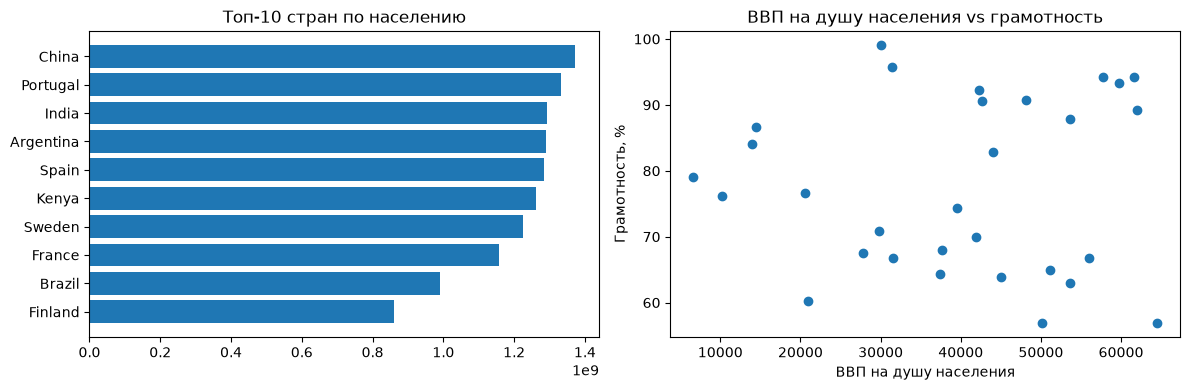

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

top10 = countries_df.nlargest(10, "Population")
axes[0].barh(top10["Country"], top10["Population"])
axes[0].set_title("Топ-10 стран по населению")
axes[0].invert_yaxis()

axes[1].scatter(countries_df["GDP ($ per capita)"], countries_df["Literacy (%)"])
axes[1].set_xlabel("ВВП на душу населения")
axes[1].set_ylabel("Грамотность, %")
axes[1].set_title("ВВП на душу населения vs грамотность")

plt.tight_layout()
plt.show()


Pandas DataFrame (litw-win):
    rank lemma   pos      ipm
0     1     с    pr  11201.2
1     2   дом     s   9014.6
2     3     а    cj   6469.0
3     4  глаз     s   4357.7
4     5    ты  spro   2715.0

NumPy structured array:
 [(1, 'с', 'pr', 11201.2) (2, 'дом', 's',  9014.6) (3, 'а', 'cj',  6469. )
 (4, 'глаз', 's',  4357.7) (5, 'ты', 'spro',  2715. )]

среднее значение частоты (ipm) по словам: 813.4 | то же через NumPy: 813.4


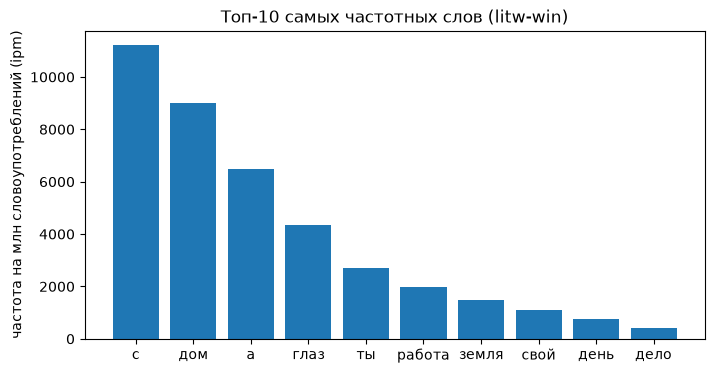

In [11]:
# --- litw-win: частотный список слов, кодировка windows-1251
litw_df = pd.read_csv(DATA / "litw-win.csv", sep=";", encoding="windows-1251")
litw_np = np.genfromtxt(DATA / "litw-win.csv", delimiter=";", names=True, dtype=None, encoding="windows-1251")

print("Pandas DataFrame (litw-win):\n", litw_df.head())
print("\nNumPy structured array:\n", litw_np[:5])
print("\nсреднее значение частоты (ipm) по словам:", litw_df["ipm"].mean().round(1),
      "| то же через NumPy:", round(float(np.mean(litw_np["ipm"])), 1))

fig, ax = plt.subplots(figsize=(8, 4))
top_words = litw_df.nlargest(10, "ipm")
ax.bar(top_words["lemma"], top_words["ipm"])
ax.set_title("Топ-10 самых частотных слов (litw-win)")
ax.set_ylabel("частота на млн словоупотреблений (ipm)")
plt.show()


Pandas DataFrame (addres-book-q):
                name  gender        company
0    Михаил Соколов    male  ООО ТехноПром
1      Анна Егорова  female  ООО ТехноПром
2    Михаил Соколов    male  ООО ТехноПром
3  Татьяна Голубева  female     ООО Глобус
4    Михаил Соколов    male    ООО Ромашка

NumPy structured array:
 [('Михаил Соколов', 'male', 'ООО ТехноПром')
 ('Анна Егорова', 'female', 'ООО ТехноПром')
 ('Михаил Соколов', 'male', 'ООО ТехноПром')
 ('Татьяна Голубева', 'female', 'ООО Глобус')
 ('Михаил Соколов', 'male', 'ООО Ромашка')]

В этом датасете нет числовых столбцов, поэтому 'среднее по столбцу' не применимо;
вместо этого — распределение по категориальному признаку (пол):
gender
male      12
female    12
Name: count, dtype: int64


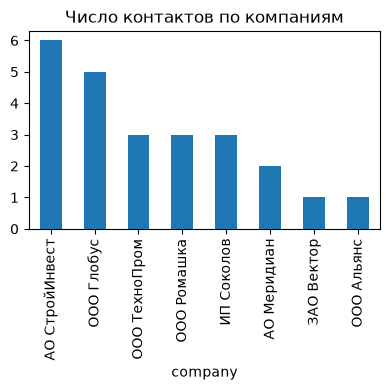

In [12]:
# --- addres-book-q.xml: не табличный числовой формат -> смысловых "средних по столбцам" нет,
# зато можно построить сводную статистику по категориальным полям.
with open(DATA / "addres-book-q.xml", encoding="utf-8") as f:
    soup = BeautifulSoup(f, "xml")

records = [
    {
        "name": p.find("name").get_text(),
        "gender": p["gender"],
        "company": p.find("company").get_text(),
    }
    for p in soup.find_all("person")
]
address_df = pd.DataFrame(records)
print("Pandas DataFrame (addres-book-q):\n", address_df.head())

address_np = np.array([(r["name"], r["gender"], r["company"]) for r in records],
                       dtype=[("name", "U64"), ("gender", "U8"), ("company", "U64")])
print("\nNumPy structured array:\n", address_np[:5])

print("\nВ этом датасете нет числовых столбцов, поэтому 'среднее по столбцу' не применимо;")
print("вместо этого — распределение по категориальному признаку (пол):")
print(address_df["gender"].value_counts())

fig, ax = plt.subplots(figsize=(4, 4))
address_df["company"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Число контактов по компаниям")
plt.tight_layout()
plt.show()
